# AI readiness and private AI investment

Exploring whether stronger AI readiness is associated with greater private AI investment, with a focus on Southeast Asia.


## Initial exploration

I started with a small Southeast Asian dataset to explore the variables and get familiar with the analysis.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

countries = ["Vietnam", "Singapore", "Malaysia", "Indonesia", "Thailand", "Philippines"]

policy_capacity = [53.5, 85.0, 80.5, 77.0, 88.0, 84.5]
governance = [56.21, 73.28, 57.33, 56.21, 57.58, 48.11]
ai_infrastructure = [65.55, 78.30, 78.48, 71.25, 75.44, 70.84]
ai_investment = [123, 1310, 759, 91, 73, 30]

data = pd.DataFrame({
    "Country": countries,
    "Policy Capacity": policy_capacity,
    "Governance": governance,
    "AI Infrastructure": ai_infrastructure,
    "AI Investment": ai_investment
})

data["Enabling Readiness"] = data[
    ["Policy Capacity", "Governance", "AI Infrastructure"]
].mean(axis=1)

print(data)

       Country  Policy Capacity  Governance  AI Infrastructure  AI Investment  \
0      Vietnam             53.5       56.21              65.55            123   
1    Singapore             85.0       73.28              78.30           1310   
2     Malaysia             80.5       57.33              78.48            759   
3    Indonesia             77.0       56.21              71.25             91   
4     Thailand             88.0       57.58              75.44             73   
5  Philippines             84.5       48.11              70.84             30   

   Enabling Readiness  
0           58.420000  
1           78.860000  
2           72.103333  
3           68.153333  
4           73.673333  
5           67.816667  


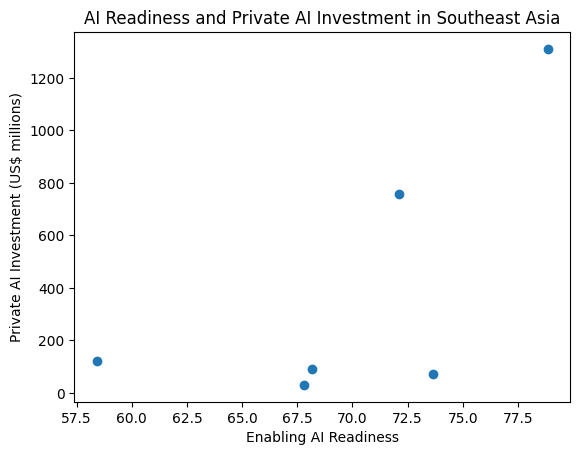

In [17]:
import matplotlib.pyplot as plt

plt.scatter(data["Enabling Readiness"], data["AI Investment"])
plt.xlabel("Enabling AI Readiness")
plt.ylabel("Private AI Investment (US$ millions)")
plt.title("AI Readiness and Private AI Investment in Southeast Asia")
plt.show()

In [18]:
correlation = data["Enabling Readiness"].corr(data["AI Investment"])

print(correlation)

0.6741638427106408


In [19]:
without_singapore = data[data["Country"] != "Singapore"]

print(without_singapore)

       Country  Policy Capacity  Governance  AI Infrastructure  AI Investment  \
0      Vietnam             53.5       56.21              65.55            123   
2     Malaysia             80.5       57.33              78.48            759   
3    Indonesia             77.0       56.21              71.25             91   
4     Thailand             88.0       57.58              75.44             73   
5  Philippines             84.5       48.11              70.84             30   

   Enabling Readiness  
0           58.420000  
2           72.103333  
3           68.153333  
4           73.673333  
5           67.816667  


In [20]:
correlation_without_singapore = without_singapore["Enabling Readiness"].corr(
    without_singapore["AI Investment"]
)

print(correlation_without_singapore)

0.3199664324088852


In [21]:
for country in countries:
    subset = data[data["Country"] != country]
    correlation = subset["Enabling Readiness"].corr(subset["AI Investment"])
    print(country, correlation)

Vietnam 0.8222698941411739
Singapore 0.3199664324088852
Malaysia 0.667267745061387
Indonesia 0.6727695691482776
Thailand 0.8253336395324748
Philippines 0.6723791405111639


In [22]:
import numpy as np

data["Log AI Investment"] = np.log(data["AI Investment"])

print(data[["Country", "AI Investment", "Log AI Investment"]])

       Country  AI Investment  Log AI Investment
0      Vietnam            123           4.812184
1    Singapore           1310           7.177782
2     Malaysia            759           6.632002
3    Indonesia             91           4.510860
4     Thailand             73           4.290459
5  Philippines             30           3.401197


In [23]:
log_correlation = data["Enabling Readiness"].corr(data["Log AI Investment"])

print(log_correlation)

0.5327764598063417


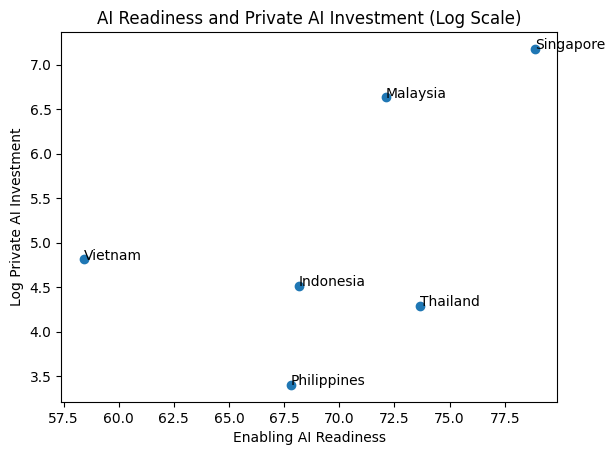

In [24]:
plt.scatter(data["Enabling Readiness"], data["Log AI Investment"])

plt.xlabel("Enabling AI Readiness")
plt.ylabel("Log Private AI Investment")
plt.title("AI Readiness and Private AI Investment (Log Scale)")

for i in range(len(data)):
    plt.text(
        data["Enabling Readiness"][i],
        data["Log AI Investment"][i],
        data["Country"][i]
    )

plt.show()

In [25]:
gdp_2025 = [514.7, 603.87, 472.19, 1445.64, 577.01, 487.09]

data["GDP 2025"] = gdp_2025

print(data[["Country", "GDP 2025", "AI Investment"]])

       Country  GDP 2025  AI Investment
0      Vietnam    514.70            123
1    Singapore    603.87           1310
2     Malaysia    472.19            759
3    Indonesia   1445.64             91
4     Thailand    577.01             73
5  Philippines    487.09             30


In [26]:
gdp_correlation = data["GDP 2025"].corr(data["AI Investment"])

print(gdp_correlation)

-0.23247779761755846


In [27]:
summary = pd.DataFrame({
    "Variable": [
        "Enabling Readiness vs AI Investment",
        "Enabling Readiness vs Log AI Investment",
        "GDP 2025 vs AI Investment",
    ],
    "Correlation": [
        data["Enabling Readiness"].corr(data["AI Investment"]),
        data["Enabling Readiness"].corr(data["Log AI Investment"]),
        data["GDP 2025"].corr(data["AI Investment"]),

    ]
})

print(summary)

                                  Variable  Correlation
0      Enabling Readiness vs AI Investment     0.674164
1  Enabling Readiness vs Log AI Investment     0.532776
2                GDP 2025 vs AI Investment    -0.232478


In [28]:
without_malaysia = data[data["Country"] != "Malaysia"]

correlation_without_malaysia = without_malaysia[
    "Enabling Readiness"
].corr(
    without_malaysia["AI Investment"]
)

print(correlation_without_malaysia)

0.667267745061387


In [29]:
without_singapore_malaysia = data[
    ~data["Country"].isin(["Singapore", "Malaysia"])
]

correlation_without_both = without_singapore_malaysia[
    "Enabling Readiness"
].corr(
    without_singapore_malaysia["AI Investment"]
)

print(correlation_without_both)

-0.6023838414461878


In [30]:
startup_ecosystem = [2.697, 37.736, 5.080, 6.397, 2.931, 2.224]

data["Startup Ecosystem"] = startup_ecosystem

print(data[["Country", "Startup Ecosystem", "AI Investment"]])

       Country  Startup Ecosystem  AI Investment
0      Vietnam              2.697            123
1    Singapore             37.736           1310
2     Malaysia              5.080            759
3    Indonesia              6.397             91
4     Thailand              2.931             73
5  Philippines              2.224             30


In [31]:
startup_correlation = data["Startup Ecosystem"].corr(
    data["AI Investment"]
)

print(startup_correlation)

0.8716852981928979


In [32]:
without_singapore = data[data["Country"] != "Singapore"]

startup_without_singapore = without_singapore[
    "Startup Ecosystem"
].corr(
    without_singapore["AI Investment"]
)

print(startup_without_singapore)

0.4067170295834397


In [33]:
ai_talent = [13, 13, 8, 22, 8, 11]

data["AI Talent"] = ai_talent

print(data[["Country", "AI Talent", "AI Investment"]])

       Country  AI Talent  AI Investment
0      Vietnam         13            123
1    Singapore         13           1310
2     Malaysia          8            759
3    Indonesia         22             91
4     Thailand          8             73
5  Philippines         11             30


In [34]:
talent_correlation = data["AI Talent"].corr(
    data["AI Investment"]
)

print(talent_correlation)

-0.16308918817367177


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Global analysis
The initial SEA analysis was useful for exploring the question, but I wanted to see whether the relationship held across a much larger group of countries. I therefore moved to the Oxford Insights 2023 Government AI Readiness Index and Stanford AI Index / Quid 2024 private investment data.

In [36]:
import pandas as pd

stanford_data = pd.read_csv(
    "/content/drive/MyDrive/AI_investment_project/fig_4.3.8.csv"
)

stanford_data.head()

,Geographic area,Total Investment (in Billions of U.S. Dollars)
0,United States,109.077326
1,China,9.290338
2,United Kingdom,4.519300
3,Sweden,4.335661
4,Canada,2.887230


In [37]:
oxford_data = pd.read_excel(
    "/content/drive/MyDrive/AI_investment_project/2023-Government-AI-Readiness-Index-Public-Indicator-Data.xlsx"
)

oxford_data.head()

,2023 Ranking,Country,Total
0,1,United States of America,84.796171
1,2,Singapore,81.970965
2,3,United Kingdom of Great Britain and Northern I...,78.572230
3,4,Finland,77.365141
4,5,Canada,77.068893


In [38]:
# Make simpler copies of the two datasets
stanford_clean = stanford_data.rename(columns={
    "Geographic area": "Country",
    "Total Investment (in Billions of U.S. Dollars)": "AI Investment 2024"
})

oxford_clean = oxford_data.rename(columns={
    "Total": "AI Readiness 2023"
})

# Make country names consistent
oxford_clean["Country"] = oxford_clean["Country"].replace({
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Viet Nam": "Vietnam"
})

# Merge the datasets
global_data = stanford_clean.merge(
    oxford_clean[["Country", "AI Readiness 2023"]],
    on="Country",
    how="inner"
)

print(global_data)
print("Number of matched countries:", len(global_data))

                 Country  AI Investment 2024  AI Readiness 2023
0          United States          109.077326          84.796171
1                  China            9.290338          70.943449
2         United Kingdom            4.519300          78.572230
3                 Sweden            4.335661          72.554288
4                 Canada            2.887230          77.068893
5                 France            2.617394          76.074758
6                Germany            1.974363          75.261520
7   United Arab Emirates            1.772767          70.423033
8                Austria            1.505926          72.365795
9                 Israel            1.364900          65.464236
10                 India            1.160556          62.578007
11           Netherlands            1.090666          74.468996
12                 Japan            0.927028          75.075792
13                 Italy            0.863946          67.625845
14             Singapore            0.84

In [39]:
import numpy as np

asean = ["Vietnam", "Singapore", "Malaysia", "Indonesia", "Thailand", "Philippines"]

print(global_data[global_data["Country"].isin(asean)])

global_data["Log AI Investment 2024"] = np.log(global_data["AI Investment 2024"])

correlation = global_data["AI Readiness 2023"].corr(
    global_data["Log AI Investment 2024"]
)

print("Correlation:", correlation)

        Country  AI Investment 2024  AI Readiness 2023
14    Singapore            0.847717          81.970965
30     Malaysia            0.064300          68.707229
32    Indonesia            0.048500          61.034924
45      Vietnam            0.008500          54.480014
47  Philippines            0.005500          51.978209
54     Thailand            0.002148          63.032627
Correlation: 0.677877722095507


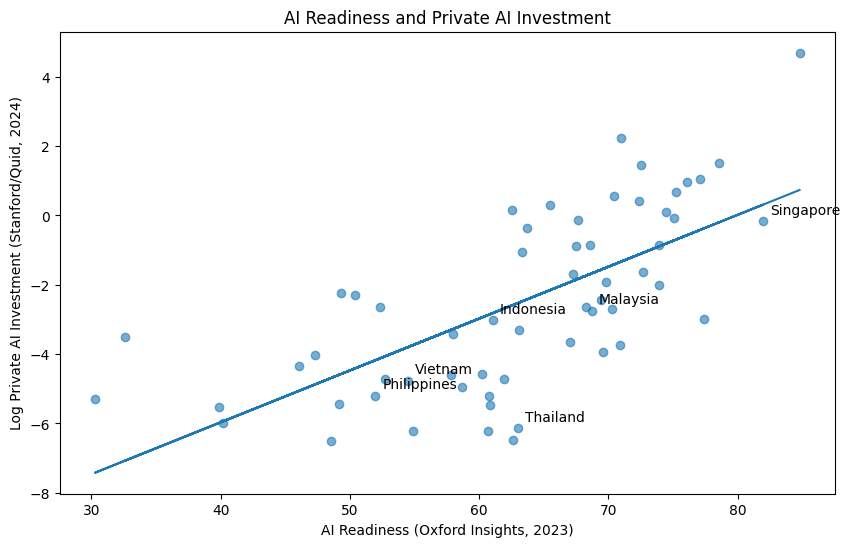

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    global_data["AI Readiness 2023"],
    global_data["Log AI Investment 2024"],
    alpha=0.6
)

# Add a trend line
x = global_data["AI Readiness 2023"]
y = global_data["Log AI Investment 2024"]
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b)

# Label the six ASEAN economies
for country in asean:
    row = global_data[global_data["Country"] == country]
    plt.annotate(
        country,
        (row["AI Readiness 2023"].iloc[0],
         row["Log AI Investment 2024"].iloc[0]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("AI Readiness (Oxford Insights, 2023)")
plt.ylabel("Log Private AI Investment (Stanford/Quid, 2024)")
plt.title("AI Readiness and Private AI Investment")

plt.show()

In [41]:
# Calculate predicted investment from the trend line
global_data["Predicted Log Investment"] = m * global_data["AI Readiness 2023"] + b

# Residual = actual minus predicted
global_data["Investment Residual"] = (
    global_data["Log AI Investment 2024"] -
    global_data["Predicted Log Investment"]
)

asean_results = global_data[
    global_data["Country"].isin(asean)
][[
    "Country",
    "AI Readiness 2023",
    "AI Investment 2024",
    "Investment Residual"
]].sort_values("Investment Residual", ascending=False)

print(asean_results)

        Country  AI Readiness 2023  AI Investment 2024  Investment Residual
32    Indonesia          61.034924            0.048500            -0.205307
14    Singapore          81.970965            0.847717            -0.475191
45      Vietnam          54.480014            0.008500            -0.966555
47  Philippines          51.978209            0.005500            -1.027742
30     Malaysia          68.707229            0.064300            -1.070661
54     Thailand          63.032627            0.002148            -3.621186


## Adding GDP

To check whether the readiness relationship was simply picking up economic size, I added 2023 GDP data from the World Bank.


In [42]:
gdp_url = "https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD?downloadformat=csv"

import requests
import zipfile
import io

response = requests.get(gdp_url)
gdp_zip = zipfile.ZipFile(io.BytesIO(response.content))

print(gdp_zip.namelist())

['Metadata_Indicator_API_NY.GDP.MKTP.CD_DS2_en_csv_v2_390497.csv', 'API_NY.GDP.MKTP.CD_DS2_en_csv_v2_390497.csv', 'Metadata_Country_API_NY.GDP.MKTP.CD_DS2_en_csv_v2_390497.csv']


In [43]:
# Find the main GDP data file inside the ZIP
gdp_file = [
    name for name in gdp_zip.namelist()
    if name.startswith("API_NY.GDP.MKTP.CD")
][0]

# Read it into pandas
gdp_data = pd.read_csv(
    gdp_zip.open(gdp_file),
    skiprows=4
)

print(gdp_data[["Country Name", "2023"]].head(10))

                  Country Name          2023
0                        Aruba  3.746573e+09
1  Africa Eastern and Southern  1.179122e+12
2                  Afghanistan  1.715223e+10
3   Africa Western and Central  9.384807e+11
4                       Angola  1.060423e+11
5                      Albania  2.349124e+10
6                      Andorra  3.785067e+09
7                   Arab World  3.617895e+12
8         United Arab Emirates  5.226223e+11
9                    Argentina  6.494617e+11


In [44]:
# Keep only country name and 2023 GDP
gdp_clean = gdp_data[["Country Name", "2023"]].copy()

gdp_clean = gdp_clean.rename(columns={
    "Country Name": "Country",
    "2023": "GDP 2023"
})

# Fix country-name differences
gdp_clean["Country"] = gdp_clean["Country"].replace({
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Türkiye": "Turkey"
})

# Merge GDP into our existing dataset
analysis_data = global_data.merge(
    gdp_clean,
    on="Country",
    how="inner"
)

print("Countries before GDP merge:", len(global_data))
print("Countries after GDP merge:", len(analysis_data))

Countries before GDP merge: 59
Countries after GDP merge: 55


In [45]:
missing_countries = global_data[
    ~global_data["Country"].isin(gdp_clean["Country"])
]["Country"]

print(missing_countries)

29      Taiwan
43       Egypt
45     Vietnam
48    Slovakia
Name: Country, dtype: object


In [46]:
# Fix country-name differences
gdp_clean["Country"] = gdp_clean["Country"].replace({
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Türkiye": "Turkey",
    "Taiwan, China": "Taiwan",
    "Egypt, Arab Rep.": "Egypt",
    "Viet Nam": "Vietnam",
    "Slovak Republic": "Slovakia"
})

In [47]:
analysis_data = global_data.merge(
    gdp_clean,
    on="Country",
    how="inner"
)

print("Countries before GDP merge:", len(global_data))
print("Countries after GDP merge:", len(analysis_data))

Countries before GDP merge: 59
Countries after GDP merge: 58


In [48]:
missing_country = global_data[
    ~global_data["Country"].isin(gdp_clean["Country"])
]["Country"]

print(missing_country)

29    Taiwan
Name: Country, dtype: object


In [49]:
import statsmodels.api as sm
import numpy as np

# Log GDP because GDP is also extremely skewed
analysis_data["Log GDP 2023"] = np.log(analysis_data["GDP 2023"])

# Outcome
y = analysis_data["Log AI Investment 2024"]

# Predictors: AI readiness + GDP
X = analysis_data[["AI Readiness 2023", "Log GDP 2023"]]

# Add an intercept
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Log AI Investment 2024   R-squared:                       0.650
Model:                                OLS   Adj. R-squared:                  0.637
Method:                     Least Squares   F-statistic:                     50.99
Date:                    Sun, 20 Sep 2026   Prob (F-statistic):           2.98e-13
Time:                            12:22:44   Log-Likelihood:                -107.25
No. Observations:                      58   AIC:                             220.5
Df Residuals:                          55   BIC:                             226.7
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

## Final chart


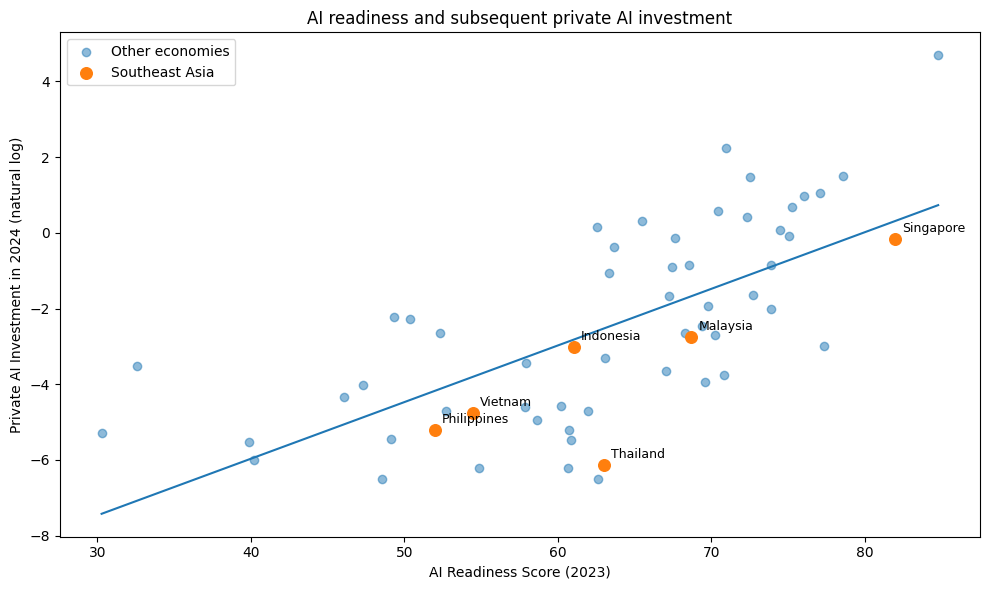

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Identify the six ASEAN economies
asean = [
    "Singapore",
    "Malaysia",
    "Indonesia",
    "Vietnam",
    "Thailand",
    "Philippines"
]

# Plot all 59 economies
plt.figure(figsize=(10, 6))

# Separate ASEAN economies from the rest of the sample
asean_mask = global_data["Country"].isin(asean)

# Plot the other economies
plt.scatter(
    global_data.loc[~asean_mask, "AI Readiness 2023"],
    global_data.loc[~asean_mask, "Log AI Investment 2024"],
    alpha=0.5,
    label="Other economies"
)

# Plot ASEAN economies separately
plt.scatter(
    global_data.loc[asean_mask, "AI Readiness 2023"],
    global_data.loc[asean_mask, "Log AI Investment 2024"],
    s=70,
    label="Southeast Asia"
)

# Add the global fitted relationship
x = global_data["AI Readiness 2023"]
y = global_data["Log AI Investment 2024"]

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line)

# Label the six ASEAN economies
for country in asean:
    row = global_data[global_data["Country"] == country]

    if not row.empty:
        plt.annotate(
            country,
            (
                row["AI Readiness 2023"].iloc[0],
                row["Log AI Investment 2024"].iloc[0]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("AI Readiness Score (2023)")
plt.ylabel("Private AI Investment in 2024 (natural log)")
plt.title("AI readiness and subsequent private AI investment")
plt.legend()
plt.tight_layout()

# Save a high-resolution version for Substack
plt.savefig(
    "/content/ai_readiness_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()